# Water Quality Prediction using Deep Learning

This notebook aims to predict the **Water Quality Index (WQI)** and **Water Quality Classification** using deep learning neural networks based on the dataset provided by the Central Pollution Control Board (CPCB).

### Project Overview:
- **Target variable for Regression:** Water Quality Index (WQI)
- **Target variable for Classification:** Water Quality Classification
- **Features:** Chemical and physical parameters such as pH, EC, HCO3, Cl, SO4, NO3, etc.

---

## 1. Setup and Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, accuracy_score, f1_score, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

TensorFlow version: 2.21.0
NumPy version: 2.4.4
Pandas version: 2.3.3


## 2. Data Loading and Cleaning

In [2]:
file_path = "Dataset/WknaT6YxR02YeXYuMDPg_water_quality.csv"

# Preprocess the CSV file to ignore the garbage text in the first line
with open(file_path, 'r', encoding='latin1') as f:
    first_line = f.readline()
    header_start = first_line.find("Well_ID")
    cleaned_header = first_line[header_start:].strip()

# Reading the actual data skipping the garbage first line
df = pd.read_csv(file_path, skiprows=1, header=None, encoding='latin1')
columns = cleaned_header.split(',')
df.columns = columns

print("Initial DataFrame Head:")
display(df.head())
print("Shape:", df.shape)

Initial DataFrame Head:


,Well_ID,State,District,Block,Village,Latitude,Longitude,Year,pH,EC,...,NO3,TH,Ca,Mg,Na,K,F,TDS,WQI,Water Quality Classification
0,W232200071580001,Gujarat,Ahmedabad,Mandal,Dalod,NaN,NaN,2020,8.20,16640.0,...,26.00,1451.0,152.0,260.0,3535.0,45.0,1.00,11149,4361.44080,Unsuitable for Drinking
1,W254029084355301,Himachal Pradesh,Solan,Nallagarh,JAGATPUR,31.1594,76.678500,2019,8.44,299.0,...,2.70,84.0,17.0,10.0,39.0,2.4,0.20,262,85.80466,Good
2,W193530074180001,Maharashtra,Ahmednagar,SANGAMNER,Kokangaon,74.3000,19.591667,2022,7.90,1315.0,...,18.20,465.0,80.2,64.4,88.3,1.6,0.53,372,280.04130,Very Poor yet Drinkable
3,W231620072033001,Gujarat,Ahmedabad,Viramgam,Endla,NaN,NaN,2020,7.40,715.0,...,0.23,280.0,56.0,34.0,47.0,11.0,0.46,479,195.11649,Poor
4,W251908084361501,Himachal Pradesh,Solan,Nallagarh,BARUNA,31.1540,76.638400,2019,8.40,270.0,...,10.00,116.0,10.0,18.0,23.0,1.0,0.12,262,81.77860,Good


Shape: (19029, 24)


## 3. Exploratory Data Analysis (EDA)

In [4]:
# Drop non-essential columns for prediction
drop_cols = ['Well_ID', 'State', 'District', 'Block', 'Village']
data = df.drop(columns=drop_cols)

# Ensure all feature columns are numeric
feature_cols = ['pH', 'EC', 'CO3', 'HCO3', 'Cl', 'SO4', 'NO3', 'TH', 'Ca', 'Mg', 'Na', 'K', 'F', 'TDS', 'Latitude', 'Longitude', 'Year']
for col in feature_cols + ['WQI']:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Summary of missing values
print("Missing values pre-cleaning:")
print(data.isnull().sum())

# Drop rows where targets are NaN
data = data.dropna(subset=['WQI', 'Water Quality Classification'])

# Fill feature NaNs with median
data[feature_cols] = data[feature_cols].apply(lambda x: x.fillna(x.median()))

print("Post-cleaning shape:", data.shape)

Missing values pre-cleaning:
Latitude                        389
Longitude                       390
Year                              0
pH                                0
EC                                0
CO3                               0
HCO3                              0
Cl                                0
SO4                               0
NO3                               0
TH                                0
Ca                                0
Mg                                0
Na                                0
K                                 0
F                                 0
TDS                               0
WQI                               0
Water Quality Classification      0
dtype: int64
Post-cleaning shape: (19029, 19)


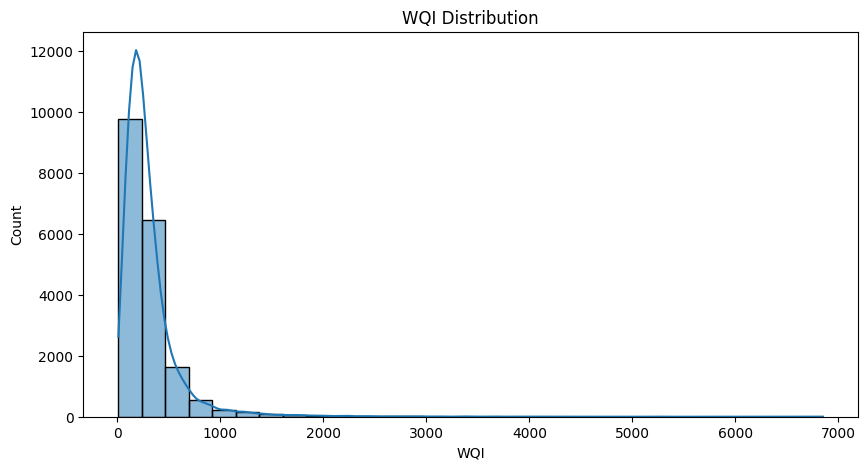

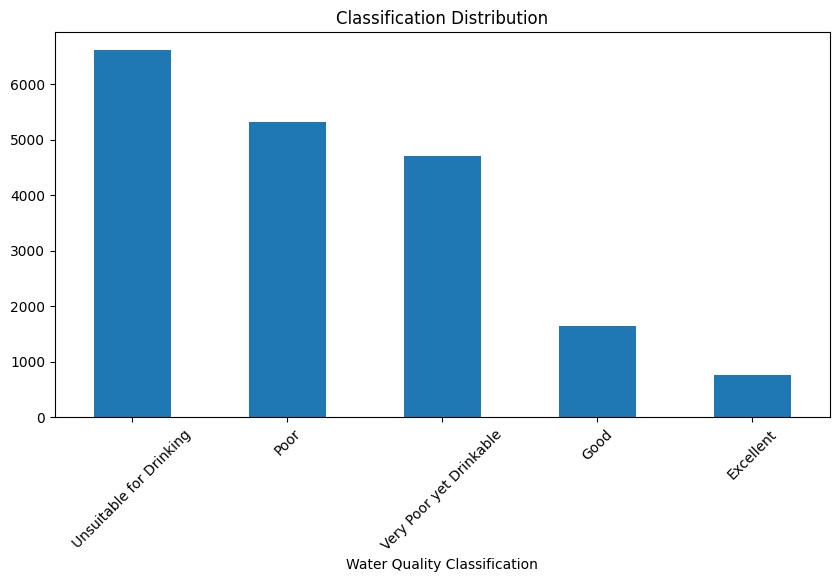

In [5]:
# Visualizing distributions of WQI
plt.figure(figsize=(10, 5))
sns.histplot(data['WQI'], bins=30, kde=True)
plt.title('WQI Distribution')
plt.show()

# Class distribution
plt.figure(figsize=(10, 5))
data['Water Quality Classification'].value_counts().plot(kind='bar')
plt.title('Classification Distribution')
plt.xticks(rotation=45)
plt.show()

## 4. Data Preprocessing and Splitting

In [6]:
# Encoding the categorical target
le = LabelEncoder()
data['Class_Encoded'] = le.fit_transform(data['Water Quality Classification'].astype(str))

X = data[feature_cols]
y_reg = data['WQI']
y_cls = data['Class_Encoded']

# Train-test split for regression
X_train, X_test, y_reg_train, y_reg_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)
# Same split approach for classification to maintain consistency if needed (or separate splits)
_, _, y_cls_train, y_cls_test = train_test_split(X, y_cls, test_size=0.2, random_state=42)

# Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train.shape)
print("Number of classes:", len(le.classes_))
print("Classes mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Training data shape: (15223, 17)
Number of classes: 5
Classes mapping: {'Excellent': np.int64(0), 'Good': np.int64(1), 'Poor': np.int64(2), 'Unsuitable for Drinking': np.int64(3), 'Very Poor yet Drinkable': np.int64(4)}


## 5. Regression Model for WQI

In [7]:
def build_regression_model():
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)  # Linear output for regression
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

reg_model = build_regression_model()
print(reg_model.summary())

# Train with early stopping
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history_reg = reg_model.fit(
    X_train_scaled, y_reg_train, 
    validation_split=0.1, 
    epochs=100, 
    batch_size=32, 
    callbacks=[early_stop], 
    verbose=1
)

z:\AV_Projects\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,777 (14.75 KB)

 Trainable params: 3,777 (14.75 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
429/429 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 67989.9297 - mae: 156.8146 - val_loss: 6503.7603 - val_mae: 53.4311
Epoch 2/100
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4508.6001 - mae: 40.4440 - val_loss: 2472.4768 - val_mae: 33.0931
Epoch 3/100
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1862.3302 - mae: 25.0072 - val_loss: 1204.4653 - val_mae: 19.3300
Epoch 4/100
429/429 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 879.0530 - mae: 15.1120 - val_loss: 726.8878 - val_mae: 12.6606
Epoch 5/100
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 501.4748 - mae: 10.2812 - val_loss: 497.8201 - val_mae: 9.2185
Epoch 6/100
429/429 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 311.9406 - mae: 8.1882 - val_loss: 360.3685 - val_mae: 7.3723
Epoch 7/100
429/429 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 208.7644 - mae: 6.7586 - val_loss: 256.2401 - val_mae: 6.4551
Epoch 8/100
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 140.8862 - mae: 5.9505 - val_loss: 174.1823 - val_mae: 5

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
R² Score: 1.0000


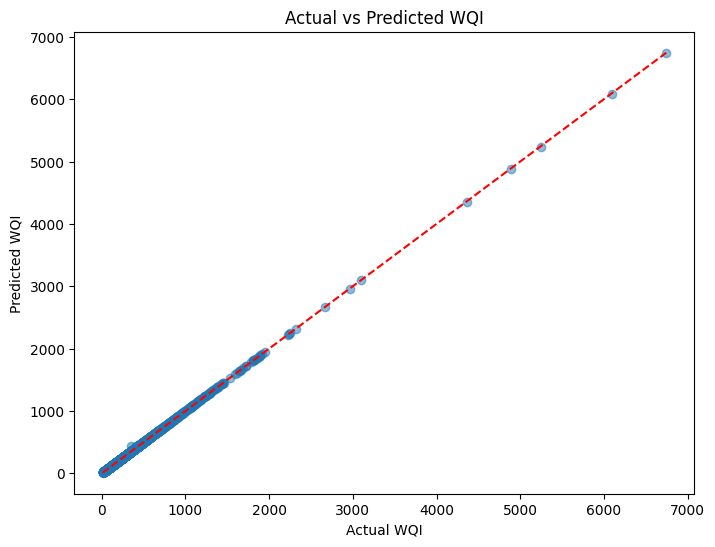

In [8]:
# Regression Model Evaluation
y_reg_pred = reg_model.predict(X_test_scaled)
r2 = r2_score(y_reg_test, y_reg_pred)
print(f"R² Score: {r2:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_reg_test, y_reg_pred, alpha=0.5)
plt.plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], 'r--')
plt.xlabel('Actual WQI')
plt.ylabel('Predicted WQI')
plt.title('Actual vs Predicted WQI')
plt.show()

## 6. Classification Model for Water Quality Classification

In [9]:
def build_classification_model():
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(len(le.classes_), activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

cls_model = build_classification_model()
print(cls_model.summary())

history_cls = cls_model.fit(
    X_train_scaled, y_cls_train, 
    validation_split=0.1, 
    epochs=100, 
    batch_size=32, 
    callbacks=[early_stop], 
    verbose=1
)

z:\AV_Projects\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,845 (15.02 KB)

 Trainable params: 3,845 (15.02 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
429/429 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7615 - loss: 0.6132 - val_accuracy: 0.9035 - val_loss: 0.2362
Epoch 2/100
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9251 - loss: 0.2041 - val_accuracy: 0.9343 - val_loss: 0.1485
Epoch 3/100
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9433 - loss: 0.1474 - val_accuracy: 0.9396 - val_loss: 0.1340
Epoch 4/100
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9563 - loss: 0.1158 - val_accuracy: 0.9691 - val_loss: 0.0897
Epoch 5/100
429/429 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9623 - loss: 0.0978 - val_accuracy: 0.9665 - val_loss: 0.0833
Epoch 6/100
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9679 - loss: 0.0834 - val_accuracy: 0.9593 - val_loss: 0.0895
Epoch 7/100
429/429 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9693 - loss: 0.0774 - val_accuracy: 0.9724 - val_loss: 0.0720
Epoch 8/100
429/429 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9699 - loss: 0.0736 - val

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 0.9782
F1 Score (Weighted): 0.9782


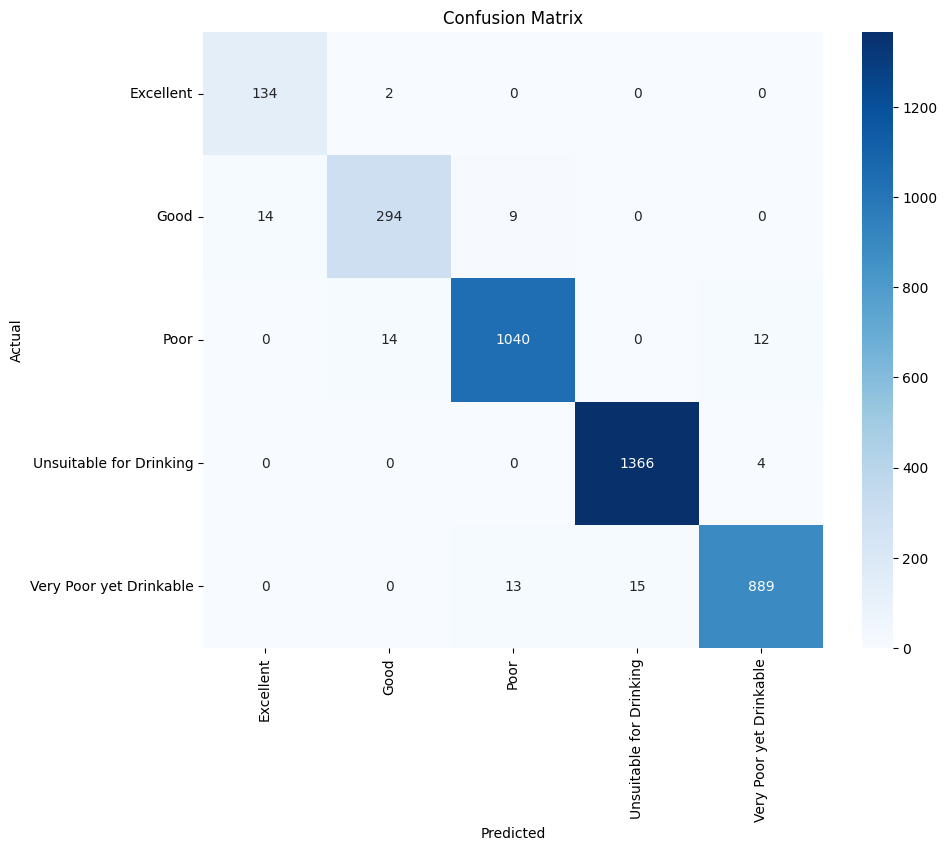

In [10]:
# Classification Model Evaluation
y_cls_pred_probs = cls_model.predict(X_test_scaled)
y_cls_pred = np.argmax(y_cls_pred_probs, axis=1)

accuracy = accuracy_score(y_cls_test, y_cls_pred)
f1 = f1_score(y_cls_test, y_cls_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score (Weighted): {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_cls_test, y_cls_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 7. Conclusions

In this project, neural network architectures were built for both regression and classification on the water quality dataset provided by the CPCB. 

Specific metrics achieved:
- **Regression (WQI):** R² Score shows how well the model explains variance in the Water Quality Index.
- **Classification (Water Quality Classification):** Accuracy and F1-score reveal the model's ability to categorize different quality levels effectively.

The data required significant cleaning due to some noise in the first line and missing values in specific parameters. Scaling all features ensured the neural networks could converge more efficiently.